In [1]:
import scanpy as sc
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt


d:\GP\Scimilarity_test\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_1 = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\Baron_Pancreas_Human_mix.h5ad")
print(adata_1)


AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch'


In [3]:
adata_1.var.head()

""
A1BG
A1CF
A2M
A2ML1
A4GALT


In [4]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [5]:
adata_1.layers["counts"] = adata_1.X.copy()


In [6]:
# add disease column, healthy for subjects 1 to 3 and diabetes tpe 2 for subject 4
adata_1.obs['disease'] = adata_1.obs['donor_id'].apply(lambda x: 'healthy' if x in ['human1', 'human2', 'human3'] else 'diabetes_type_2')

In [7]:
from scimilarity.utils import align_dataset, lognorm_counts
adata_1 = align_dataset(adata_1, ce.gene_order)
adata_1 = lognorm_counts(adata_1)

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi(adata, label_keys, embed_key,k_lisi=30):
    
    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]  
    
    
    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        sil_scores[key] = silhouette_score(X, adata.obs[key].values)
  

    # Call compute_lisi
    lisi_scores = compute_lisi(X, metadata, label_colnames=label_keys)

    # Convert to DataFrame for easier handling
    lisi_df = pd.DataFrame(lisi_scores, columns=label_keys, index=adata.obs_names)
   
    # Combine results
    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.median().to_dict()
    }
    
    return scores

In [9]:

X = adata_1.X
embeddings= ce.get_embeddings(X)
adata_1.obsm["X_emb"] = embeddings

In [10]:
print(embeddings.shape)
# save combined embeddings to project directory
adata_1.write_h5ad(r"D:\GP\Notebooks\Scimilarity\Pancreas_combined_HvD_embeddings.h5ad")


(8569, 128)


In [11]:
import scanpy as sc

In [12]:
adata_1 = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\Pancreas_combined_HvD_embeddings.h5ad")
print(adata_1)

AnnData object with n_obs × n_vars = 8569 × 28231
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'disease'
    uns: 'orig_genes'
    obsm: 'X_emb'
    layers: 'counts'


In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi_avg(adata, label_keys, embed_key, k_lisi=30):
  
    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]

    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        labels = adata.obs[key].astype(str).values
        
        if len(np.unique(labels)) > 1:
            sil_scores[key] = silhouette_score(X, labels)
        else:
            sil_scores[key] = np.nan

    # LISI scores
    lisi_scores = compute_lisi(
        X,
        metadata,
        label_colnames=label_keys,
        perplexity=k_lisi
    )

    lisi_df = pd.DataFrame(
        lisi_scores,
        columns=label_keys,
        index=adata.obs_names
    )

    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.mean().to_dict()
    }

    return scores

In [14]:
label_keys = ["cell_type", "donor_id", "disease"]
# Compute scores
scores = compute_silhouette_and_lisi_avg(adata_1, label_keys, embed_key="X_emb", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


Silhouette Scores: {'cell_type': 0.2624097764492035, 'donor_id': -0.03164476901292801, 'disease': -0.044077806174755096}
LISI Scores: {'cell_type': 1.0838738862417785, 'donor_id': 1.6472618011665652, 'disease': 1.2096988388098233}


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [16]:
import matplotlib.pyplot as plt

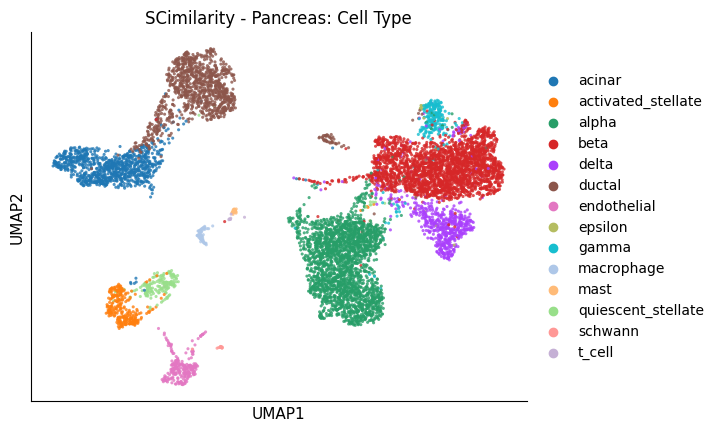

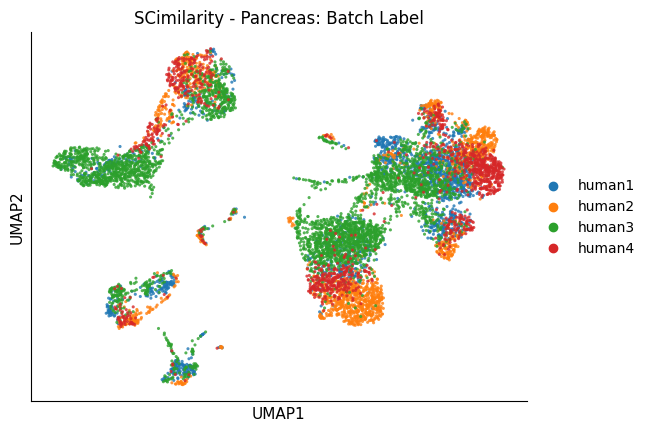

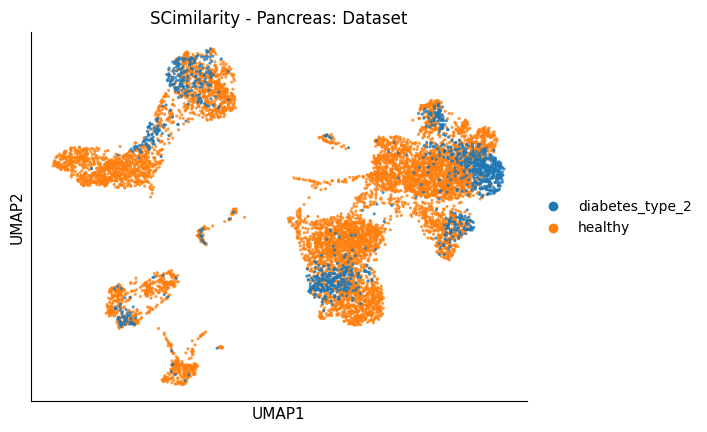

=== Logistic Regression ===
Accuracy: 0.8825786646201075
                    precision    recall  f1-score   support

            acinar       0.02      0.50      0.03         2
activated_stellate       1.00      0.98      0.99        52
             alpha       0.87      1.00      0.93       284
              beta       0.94      0.99      0.97       495
             delta       0.90      0.89      0.90       101
            ductal       1.00      0.75      0.85       280
       endothelial       0.88      1.00      0.93         7
           epsilon       0.00      0.00      0.00         1
             gamma       0.50      0.02      0.03        63
        macrophage       1.00      0.90      0.95        10
              mast       1.00      1.00      1.00         1
quiescent_stellate       0.83      1.00      0.91         5
           schwann       0.00      0.00      0.00         1
            t_cell       1.00      1.00      1.00         1

          accuracy                       

d:\GP\Scimilarity_test\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GP\Scimilarity_test\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GP\Scimilarity_test\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


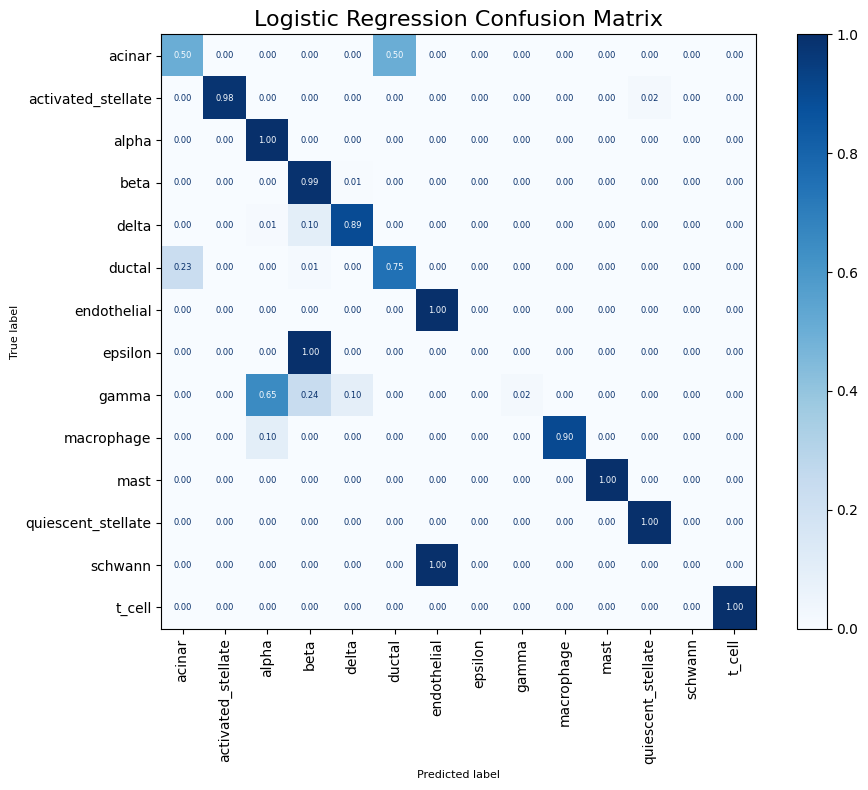


=== k-NN ===
Accuracy: 0.9347659247889486
                    precision    recall  f1-score   support

            acinar       0.02      0.50      0.04         2
activated_stellate       1.00      0.98      0.99        52
             alpha       0.97      1.00      0.98       284
              beta       0.98      0.98      0.98       495
             delta       0.93      0.96      0.95       101
            ductal       0.99      0.81      0.89       280
       endothelial       1.00      1.00      1.00         7
           epsilon       0.00      0.00      0.00         1
             gamma       0.88      0.79      0.83        63
        macrophage       1.00      1.00      1.00        10
              mast       1.00      1.00      1.00         1
quiescent_stellate       0.83      1.00      0.91         5
           schwann       1.00      1.00      1.00         1
            t_cell       1.00      1.00      1.00         1

          accuracy                           0.93      

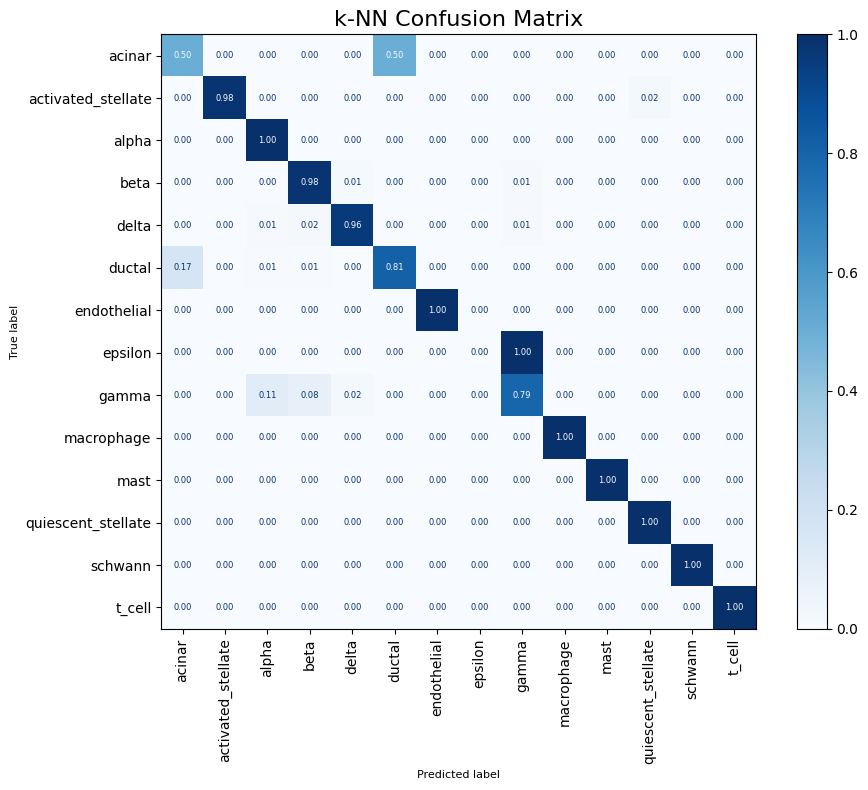

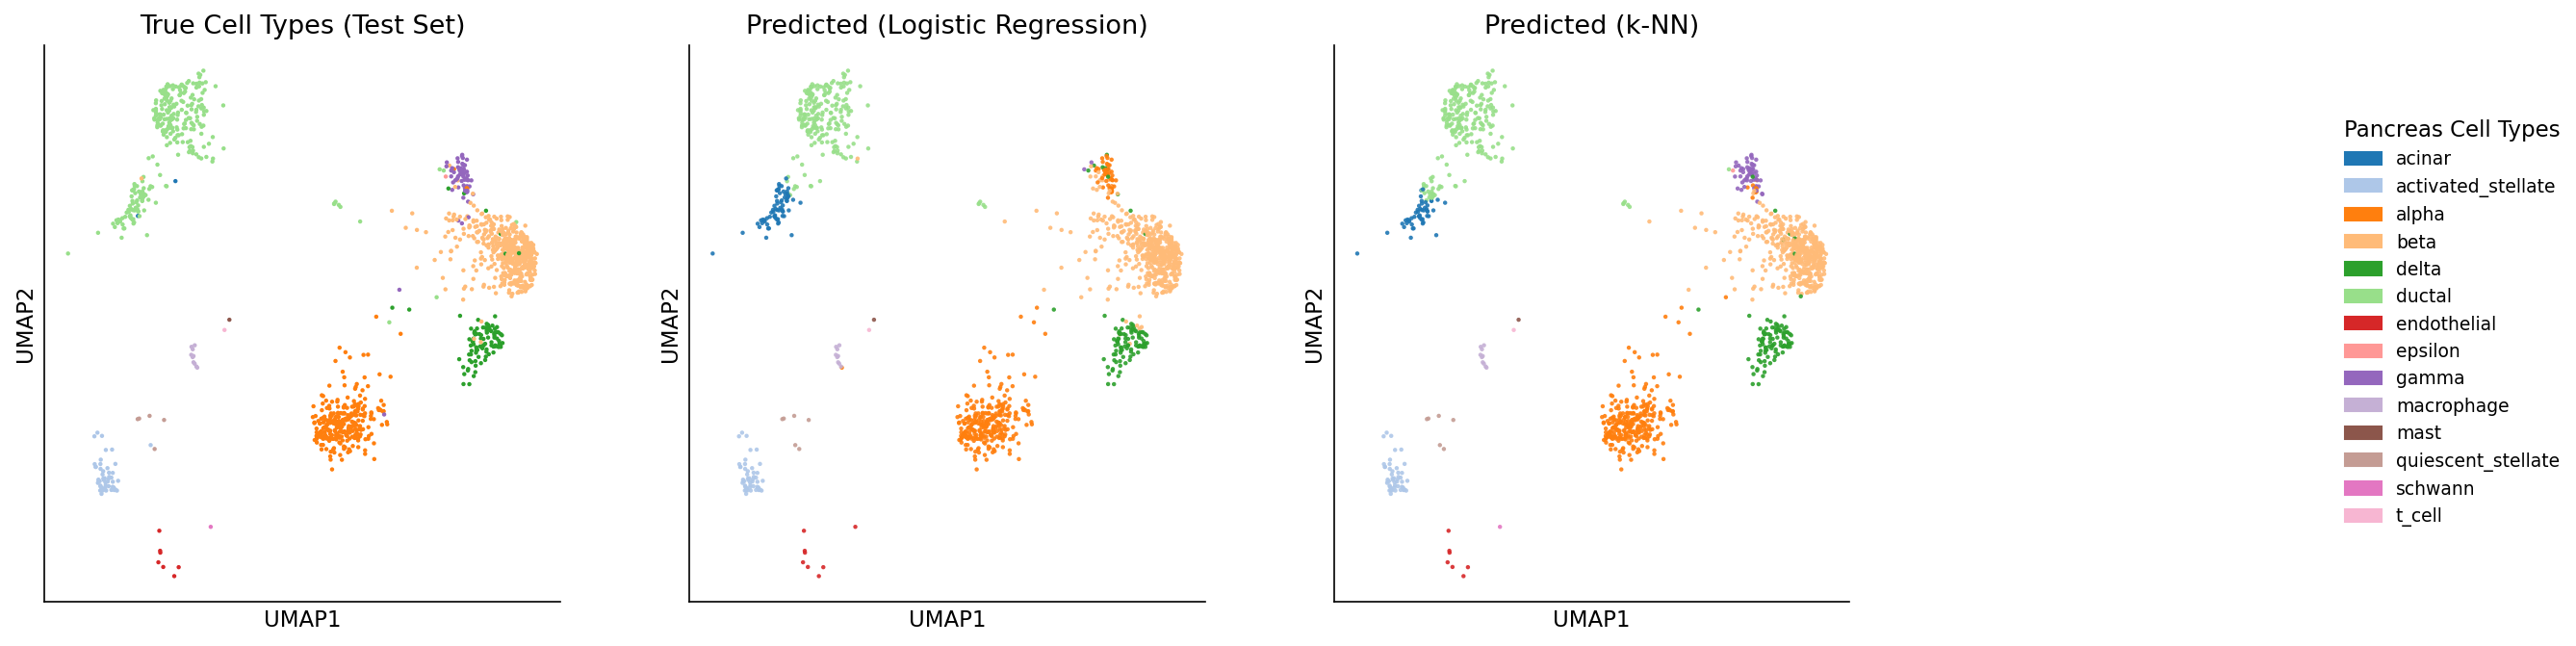

In [ ]:

## Visualization

sc.pp.neighbors(adata_1, use_rep="X_emb")
sc.tl.umap(adata_1)

ax = sc.pl.umap(
    adata_1,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Pancreas: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata_1,
    color='donor_id',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Pancreas: Batch Label"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata_1,
    color='disease',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Pancreas: Dataset"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier 

train_data = adata_1[adata_1.obs["disease"] == "healthy"].copy()
test_data = adata_1[adata_1.obs["disease"] == "diabetes_type_2"].copy()

X_train = train_data.obsm["X_emb"]
X_test  = test_data.obsm["X_emb"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()


print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["celltype"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["celltype"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["celltype"] = test_data.obs["celltype"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="celltype", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()